# LIBRARY

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [3]:
import pandas as pd

def analyze_feature(df, colonna, quantili=[0.1,0.25,0.50, 0.75,0.9,0.99]):
    serie = df[colonna] 
    
    # CAL values equal to 0
    num_zero = (serie == 0).sum()
    presenza_zero = num_zero > 0
    
    # CAL negative values
    num_negativi = (serie < 0).sum()
    presenza_negativi = num_negativi > 0
    
    # CAL range (min and max)
    valore_min = serie.min()
    valore_max = serie.max()
    range_valori = valore_max - valore_min

     # CAL quantiles
    valori_quantili = serie.quantile(quantili)
    
    # Stampa risultati
    print(f"Analyzed column: {colonna}")
    print(f"Presence of values equal to 0: {presenza_zero}")
    print(f"Number of values equal to 0: {num_zero}")
    print(f"Presence of negative values: {presenza_negativi}")
    print(f"Number of negative values: {num_negativi}")    
    print(f"Minimum value: {valore_min}")
    print(f"Maximum value: {valore_max}")
    print(f"Range (max - min): {range_valori}")

    print(f"\nQuantiles:")
    for q, v in valori_quantili.items():
        print(f"  Q{int(q*100)} ({q}): {v}")

# IMPORT DF

In [10]:
file_path = "../1.DATASET/CMI_NN_V2.csv"
df=pd.read_csv(file_path)
df.head(3)

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.0,50.8,932.498,NaN,5.0,...,1.0,19.541300,32.6909,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.5
1,1,9,0,NaN,14.035590,48.0,46.0,936.656,70.0,NaN,...,1.0,15.410700,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.0
2,2,10,1,71.0,16.648696,56.5,75.6,1115.380,94.0,5.0,...,2.0,27.022395,42.3800,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.0


In [11]:
df.columns

Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [12]:
cols=[ 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL']

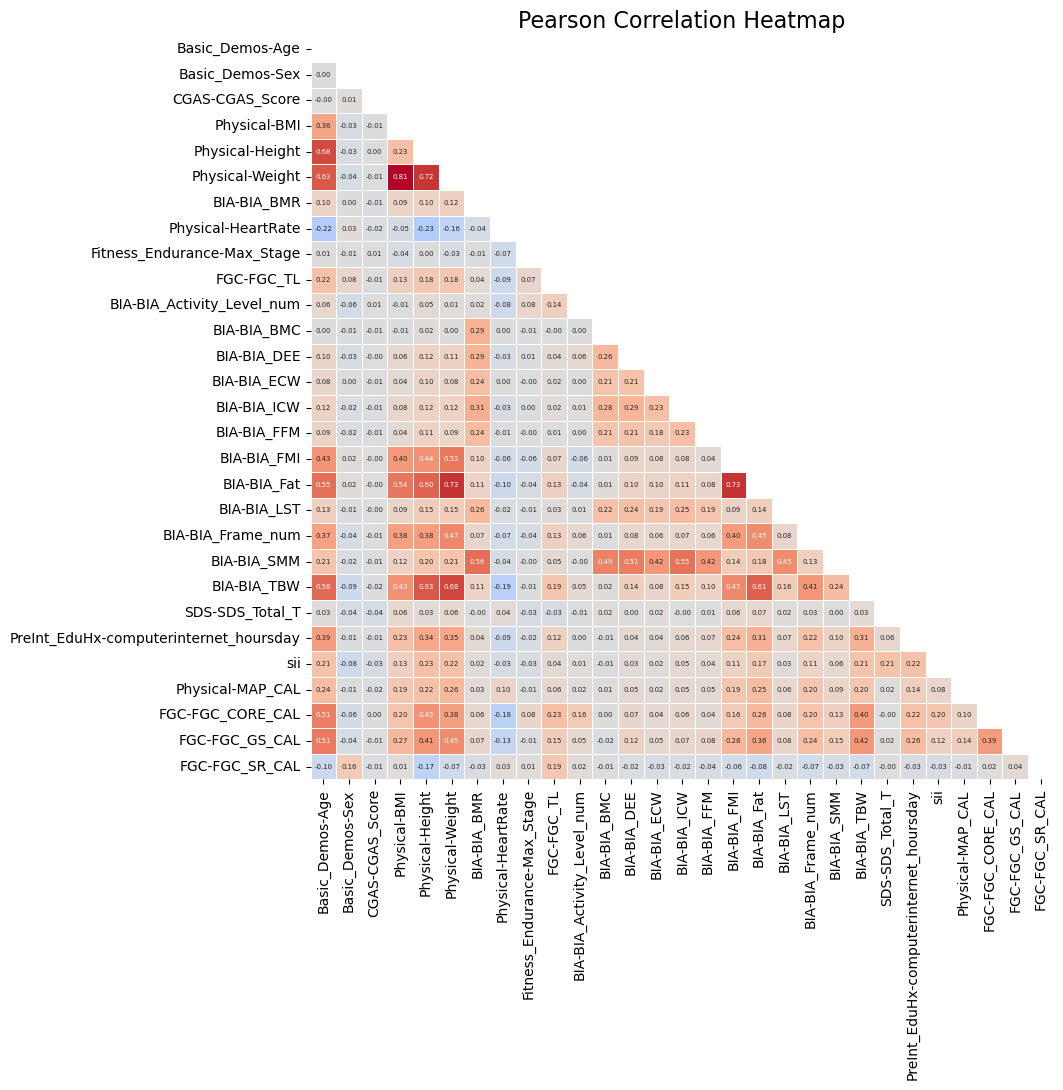

In [13]:
# column selection
df_corr = df[cols]
 
# Pearson correlation
corr = df_corr.corr(method='pearson')
 
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# heatmap
plt.figure(figsize=(11, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=False,
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8}
)
 
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()